# 이항분포 p.288, p.303

- 앞/뒤, 전/후 간의 비교를 하여 차이가 있는지 검정  
- 집단의 차이를 검정하는 2 sample t-검정 과 달리 Paired t-검정은 하나의 단위의 차이 검정

귀무가설 : 차이가 없다.  
대립가설 : 차이가 있다.

In [3]:
# df1, 
# df2를 직접 입력 
import pandas as pd
import numpy as np
from scipy import stats

df1 = pd.DataFrame({'before': [720, 589, 780, 648, 720, 589, 780, 648, 780, 648]})
df2 = pd.DataFrame({'after': [810, 670, 790, 712, 810, 670, 790, 712, 790, 712]})

솔직히 딱 봐도 데이터에 이상치, 결측치 없음...

In [4]:
# Paired t-test
t_result = stats.ttest_rel(df1, df2)

stats: scipy.stats 라이브러리를 말합니다. (통계 마법 도구함)

ttest_rel: 대응표본 t-검정 전용 함수입니다.

df1, df2: 분석할 두 데이터 집단입니다. (이미지에서는 학원 가기 전/후 성적)

In [5]:
# Paired t-test의 t값 p값 저장
t, p = t_result.statistic.round(3), t_result.pvalue.round(3)

t_result.statistic: 검정 결과에서 t-값을 가져와서,  
  
.round(3): 소수점 셋째 자리까지 반올림한 뒤,  

t_result.pvalue: 보따리에서 p-value를 꺼내라.

t, p = ...: 왼쪽의 변수 t에 저장해라! (p-value도 마찬가지로 p에 저장)

In [6]:
print( "Paired t-test ")
print( " t: {} " .format(t))
print( " p: {} " .format(p))

Paired t-test 
 t: [-5.324] 
 p: [0.] 


P값이 0이다. 유의수준보다 낮다 대립가설을 세웠을때 오류가 날 가능성이 없다 = 대립가설을 채택하도록 하겠다.

# 제미나이 문제

1. 시각적 확인 : boxplot : 이상치가 없는지?   
2. 정규성 검정 : stats.shapiro()를 실행 해서 P>0.05 임을 확인한 뒤에 ttest_rel    
- stats.shapiro(df['after'] - df['before']) → "p > 0.05이므로 t-test 가능"
3. 대응 표본은 등분산 검정을 하지 않습니다.  
4. 최종 해석

📝 [실전 손코딩 문제] 공정 개선 전/후 성능 비교 분석
데이터 상황: A 공정의 효율을 높이기 위해 새로운 시스템을 도입했습니다. 시스템 도입 전(before)과 도입 후(after)의 생산량 데이터를 얻었으나, 측정 기기 오류로 일부 데이터에 결측치(None)와 잘못된 수치(이상치)가 포함되었습니다.

[전처리] * before 혹은 after 중 하나라도 결측치(None)가 있는 행은 제거하시오.  
- 측정 오류 값인 999가 포함된 행도 제거하시오.[정규성 검정] * 개선 후와 개선 전의 차이값(after - before)을 구하고, 이 차이값이 정규분포를 따르는지 Shapiro-Wilk 검정을 통해 확인하시오. (p-value를 소수점 4자리까지 출력)  

[가설 검정] * "시스템 도입 후 생산량이 증가하였다"는 가설을 검정하기 위해 대응표본 t-검정(Paired t-test)을 수행하시오.  
- 단, 단측 검정(Greater) 옵션을 사용하고 t-통계량과 p-value를 소수점 4자리까지 출력하시오. (유의수준 $\alpha = 0.05$)  

[해석] * 검정 결과를 바탕으로 시스템 도입이 효과가 있었는지 결론을 내리시오.

가설 세우기  
귀무가설 : 시스템 도입 후 생산량이 증가하지 않았습니다.  
대립가설 : 시스템 도입 후 생산량이 증가하였다


In [13]:
import pandas as pd
import numpy as np
from scipy import stats

# 전/후 데이터 (None은 결측치, 999는 측정 오류로 인한 이상치)
data = {
    'before': [75, 82, None, 95, 70, 88, 92, 100, 85, 999],
    'after': [80, 88, 85, 98, 72, 90, 95, None, 88, 70]
}
df = pd.DataFrame(data)
df.head()

,before,after
0,75.0,80.0
1,82.0,88.0
2,NaN,85.0
3,95.0,98.0
4,70.0,72.0


#### 1. 시각화로 이상치 식별

<Axes: >

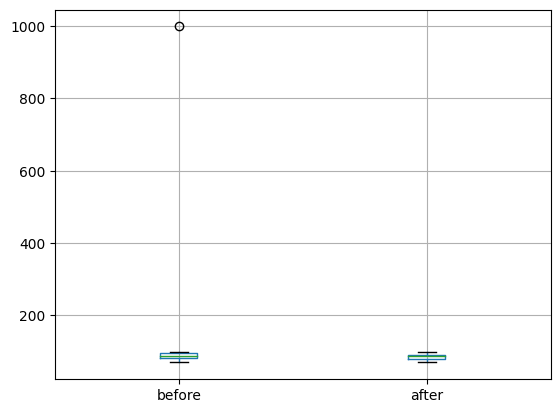

In [ ]:
# Group별 boxplot
df.boxplot()
plt.show()  # 그냥 show 하는거임!

이상치가 있다 !

#### 2. 데이터 정제

In [14]:
# 1. 이상치(999) 제거 (정상 범위를 벗어난 값 필터링)
df_clean = df[df['before'] != 999]

# 2. 결측치 제거 (짝이 안 맞는 행 삭제)
df_clean = df_clean.dropna()

#### 3. 차이값 생성 및 정규성 검정

In [17]:
# 1. 전/후 차이값 계산
diff = df_clean['after'] - df_clean['before']

# 2. 정규성 검정 수행
s_stat, p_norm = stats.shapiro(diff)
print(f"정규성 p-value: {p_norm:.4f}") 
# (p_norm > 0.05여야 T-검정 가능)

정규성 p-value: 0.1074


p-value: 0.1074가 0.05보다 크므로 "정규성을 만족한다"

#### 4단계: 가설 검정 수행 (Paired T-test)

In [21]:
# Paired t-test
# 두 집단의 평균 차이를 분석해서 결과를 보따리(t_result)에 담는 역할
# [수정] '증가'를 검정하므로 alternative='greater' 옵션을 반드시 넣습니다.
t_result = stats.ttest_rel(df_clean['before'], df_clean['after'], alternative = 'greater')

# t값, p값 
# 보따리(t_result)에서 필요한 알맹이만 꺼내서 이름표를 붙여주는 과정
t, p = t_result.statistic, t_result.pvalue

In [19]:
# Paired t-test의 t값 p값 출력
print( "Paired t-test ")
print( " t: {} " .format(t))
print( " p: {} " .format(p))

Paired t-test 
 t: -6.0 
 p: 0.9995177324027924 


In [20]:
# [수정] 해석 부분
alpha = 0.05
if p < alpha:
    print("결론: p-value가 유의수준보다 작으므로 귀무가설을 기각한다.")
    print("즉, 시스템 도입 후 생산량이 통계적으로 유의미하게 증가하였다.")
else:
    print("결론: p-value가 유의수준보다 크므로 귀무가설을 채택한다.")
    print("즉, 시스템 도입 후 생산량 증가 효과가 있다고 보기 어렵다.")

결론: p-value가 유의수준보다 크므로 귀무가설을 채택한다.
즉, 시스템 도입 후 생산량 증가 효과가 있다고 보기 어렵다.


## 혹시나 Paired가 아닐수도..? t-test

📝 [실전 문제] 기존 공정(A) vs 신규 공정(B) 비교  
상황: 기존 공정라인(A)과 신규 공정라인(B)의 일일 생산량을 비교합니다. 두 라인은 완전히 독립적이며, 데이터 개수도 다릅니다. B라인의 생산량이 A라인보다 증가했는지 검정하세요.

In [26]:
import pandas as pd
import numpy as np
from scipy import stats

# 데이터 (데이터 개수가 달라도 됨)
line_a = [75, 82, 95, 70, 88, 92, 100, 85]
line_b = [85, 92, 88, 98, 80, 95, 105, 90, 110, None] # 결측치 포함

1단계: 시각화 및 결측치 제거

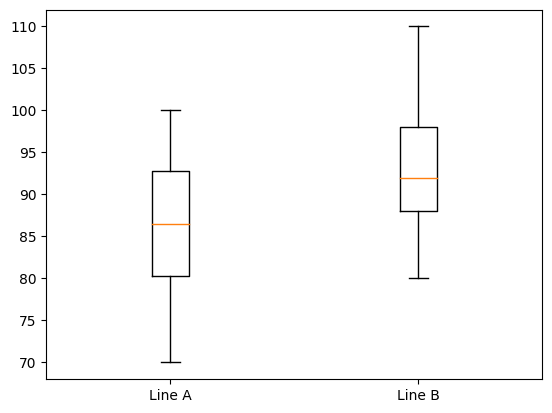

In [27]:


# Boxplot 확인 (집단이 다르므로 리스트로 묶어서 전달)
import matplotlib.pyplot as plt
plt.boxplot([line_a, line_b_clean], labels=['Line A', 'Line B'])
plt.show()

In [ ]:
# 결측치 제거 (line_b에서만)
line_b_clean = [x for x in line_b if x is not None]

2단계: 각 집단별 정규성 검정 (Shapiro)

In [28]:
# A라인 정규성
s_a, p_norm_a = stats.shapiro(line_a)
# B라인 정규성
s_b, p_norm_b = stats.shapiro(line_b_clean)

print("A 정규성 p-value: {:.4f}".format(p_norm_a))
print("B 정규성 p-value: {:.4f}".format(p_norm_b))
# 둘 다 0.05보다 커야 t-test 가능!

A 정규성 p-value: 0.9644
B 정규성 p-value: 0.9324


3단계: 등분산 검정 (Levene) - ★독립표본의 핵심 관문★

In [29]:
# p-value > 0.05 이면 분산이 같다고 판단 (equal_var=True)
# p-value < 0.05 이면 분산이 다르다고 판단 (equal_var=False)
s_levene, p_equal = stats.levene(line_a, line_b_clean)
print("등분산 검정 p-value: {:.4f}".format(p_equal))

등분산 검정 p-value: 0.8191


4단계: 가설 검정 (Independent t-test)

In [30]:
# 3단계 p_equal이 0.05보다 크다고 가정(True)하고 진행
# B가 A보다 큰지 확인하므로 alternative='greater'
t_result = stats.ttest_ind(line_b_clean, line_a, equal_var=True, alternative='greater')

t, p = t_result.statistic, t_result.pvalue
print("t-통계량: {:.4f}, p-value: {:.4f}".format(t, p))

t-통계량: 1.6384, p-value: 0.0611


5단계: 최종 해석

In [31]:
alpha = 0.05
if p < alpha:
    print("결론: p-value가 유의수준보다 작으므로 귀무가설 기각. 신규 공정(B)의 생산량이 유의미하게 증가함.")
else:
    print("결론: p-value가 유의수준보다 크므로 귀무가설 채택. 생산량 증가라고 보기 어려움.")

결론: p-value가 유의수준보다 크므로 귀무가설 채택. 생산량 증가라고 보기 어려움.
